In [111]:
import pandas as pd
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [2]:
urlLengthRailways = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_if_line_na/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'
urlNumberPassengersPerState = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_pa_total/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [3]:
df = pd.read_csv(urlNumberPassengersPerState, sep=",", compression="gzip")
df.head()

dfLength = pd.read_csv(urlLengthRailways, sep=",", compression="gzip")

In [4]:
df.describe()

,TIME_PERIOD,OBS_VALUE,OBS_FLAG
count,1377.000000,1.276000e+03,0.0
mean,2014.374728,1.511032e+05,NaN
std,6.024215,3.944371e+05,NaN
min,2004.000000,1.000000e+00,NaN
25%,2009.000000,2.402750e+03,NaN
50%,2015.000000,1.570650e+04,NaN
75%,2020.000000,8.427400e+04,NaN
max,2025.000000,2.938023e+06,NaN


In [5]:
df["freq"].unique

<bound method Series.unique of 0       Annual
1       Annual
2       Annual
3       Annual
4       Annual
         ...  
1372    Annual
1373    Annual
1374    Annual
1375    Annual
1376    Annual
Name: freq, Length: 1377, dtype: str>

In [6]:
df["freq"].value_counts()

freq
Annual    1377
Name: count, dtype: int64

In [7]:
# freq sempre Annual quindi possiamo toglierla

In [8]:
df = df.drop("DATAFLOW", axis=1)

In [9]:
df.head()

,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,02/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,02/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,02/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,02/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,02/06/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN


In [10]:
df = df.drop("LAST UPDATE", axis=1)

In [11]:
df = df.drop("freq", axis=1)

In [12]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN
...,...,...,...,...,...,...
1372,Thousand passengers,United Kingdom,2015,1741562.0,NaN,NaN
1373,Thousand passengers,United Kingdom,2016,1772563.0,NaN,NaN
1374,Thousand passengers,United Kingdom,2017,1757359.0,NaN,NaN
1375,Thousand passengers,United Kingdom,2018,1783232.0,NaN,NaN


In [13]:
df["unit"].value_counts()

unit
Millions of passenger-kilometres    710
Thousand passengers                 667
Name: count, dtype: int64

In [14]:
# Abbiamo due unite diverse millioni di passegger x chilometri e migliaia di passeggeri.
# Dobbiamo sceglierne una

In [15]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN
...,...,...,...,...,...,...
1372,Thousand passengers,United Kingdom,2015,1741562.0,NaN,NaN
1373,Thousand passengers,United Kingdom,2016,1772563.0,NaN,NaN
1374,Thousand passengers,United Kingdom,2017,1757359.0,NaN,NaN
1375,Thousand passengers,United Kingdom,2018,1783232.0,NaN,NaN


In [16]:
df = df.sort_values('OBS_VALUE')

In [17]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
389,Millions of passenger-kilometres,Liechtenstein,2007,1.0,NaN,NaN
388,Millions of passenger-kilometres,Liechtenstein,2006,1.0,NaN,NaN
391,Millions of passenger-kilometres,Liechtenstein,2009,1.0,NaN,NaN
392,Millions of passenger-kilometres,Liechtenstein,2010,1.0,NaN,NaN
396,Millions of passenger-kilometres,Liechtenstein,2014,1.0,NaN,NaN
...,...,...,...,...,...,...
1224,Thousand passengers,Poland,2020,NaN,NaN,C
1225,Thousand passengers,Poland,2021,NaN,NaN,C
1226,Thousand passengers,Poland,2022,NaN,NaN,C
1227,Thousand passengers,Poland,2023,NaN,NaN,C


In [18]:
df["OBS_VALUE"].isna().sum()

np.int64(101)

In [19]:
df['CONF_STATUS'].unique()

<StringArray>
[nan, 'C']
Length: 2, dtype: str

In [20]:
# Rimuovo OBS_VALUE = NaN

In [21]:
# df = df.dropna(subset=["OBS_VALUE"])
# Non rimuoviamo gli NA per poter fare interpolazione dei dati mancanti dopo

In [22]:
df

,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
389,Millions of passenger-kilometres,Liechtenstein,2007,1.0,NaN,NaN
388,Millions of passenger-kilometres,Liechtenstein,2006,1.0,NaN,NaN
391,Millions of passenger-kilometres,Liechtenstein,2009,1.0,NaN,NaN
392,Millions of passenger-kilometres,Liechtenstein,2010,1.0,NaN,NaN
396,Millions of passenger-kilometres,Liechtenstein,2014,1.0,NaN,NaN
...,...,...,...,...,...,...
1224,Thousand passengers,Poland,2020,NaN,NaN,C
1225,Thousand passengers,Poland,2021,NaN,NaN,C
1226,Thousand passengers,Poland,2022,NaN,NaN,C
1227,Thousand passengers,Poland,2023,NaN,NaN,C


In [23]:
df["OBS_FLAG"].value_counts()

Series([], Name: count, dtype: int64)

In [24]:
df["unit"].value_counts()

unit
Millions of passenger-kilometres    710
Thousand passengers                 667
Name: count, dtype: int64

In [25]:
df = df.drop("OBS_FLAG", axis=1)

In [26]:
df = df.drop("CONF_STATUS", axis=1)

In [27]:
df = df[df['TIME_PERIOD'] < 2025]

In [28]:
df.columns

Index(['unit', 'geo', 'TIME_PERIOD', 'OBS_VALUE'], dtype='str')

In [29]:
dfLength.columns

Index(['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_infr', 'tra_meas',
       'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'],
      dtype='str')

In [30]:
dfLength["unit"].value_counts()

unit
Kilometre    12556
Name: count, dtype: int64

In [31]:
df[df['geo'] == 'Germany']

,unit,geo,TIME_PERIOD,OBS_VALUE
127,Millions of passenger-kilometres,Germany,2021,57518.0
126,Millions of passenger-kilometres,Germany,2020,57787.0
111,Millions of passenger-kilometres,Germany,2005,74944.0
110,Millions of passenger-kilometres,Germany,2004,75903.0
112,Millions of passenger-kilometres,Germany,2006,78735.0
113,Millions of passenger-kilometres,Germany,2007,79098.0
115,Millions of passenger-kilometres,Germany,2009,81206.0
114,Millions of passenger-kilometres,Germany,2008,82428.0
116,Millions of passenger-kilometres,Germany,2010,82837.0
117,Millions of passenger-kilometres,Germany,2011,89316.0


In [32]:
df[df['unit'] == 'Millions of passenger-kilometres']

,unit,geo,TIME_PERIOD,OBS_VALUE
389,Millions of passenger-kilometres,Liechtenstein,2007,1.0
388,Millions of passenger-kilometres,Liechtenstein,2006,1.0
391,Millions of passenger-kilometres,Liechtenstein,2009,1.0
392,Millions of passenger-kilometres,Liechtenstein,2010,1.0
396,Millions of passenger-kilometres,Liechtenstein,2014,1.0
...,...,...,...,...
557,Millions of passenger-kilometres,Poland,2020,NaN
558,Millions of passenger-kilometres,Poland,2021,NaN
559,Millions of passenger-kilometres,Poland,2022,NaN
560,Millions of passenger-kilometres,Poland,2023,NaN


In [33]:
df[df['unit'] == 'Thousand passengers']

,unit,geo,TIME_PERIOD,OBS_VALUE
1061,Thousand passengers,Liechtenstein,2013,96.0
1058,Thousand passengers,Liechtenstein,2010,96.0
1060,Thousand passengers,Liechtenstein,2012,96.0
1059,Thousand passengers,Liechtenstein,2011,96.0
1057,Thousand passengers,Liechtenstein,2009,97.0
...,...,...,...,...
1224,Thousand passengers,Poland,2020,NaN
1225,Thousand passengers,Poland,2021,NaN
1226,Thousand passengers,Poland,2022,NaN
1227,Thousand passengers,Poland,2023,NaN


In [34]:
# Tolgo dati totali paesi

In [35]:
df = df[~df["geo"].str.contains("European Union", na=False)]

In [36]:
# Tengo solo unit Thousand passengers

In [37]:
df = df[~df["unit"].str.contains("Thousand passengers", na=False)]

In [38]:
df


,unit,geo,TIME_PERIOD,OBS_VALUE
389,Millions of passenger-kilometres,Liechtenstein,2007,1.0
388,Millions of passenger-kilometres,Liechtenstein,2006,1.0
391,Millions of passenger-kilometres,Liechtenstein,2009,1.0
392,Millions of passenger-kilometres,Liechtenstein,2010,1.0
396,Millions of passenger-kilometres,Liechtenstein,2014,1.0
...,...,...,...,...
557,Millions of passenger-kilometres,Poland,2020,NaN
558,Millions of passenger-kilometres,Poland,2021,NaN
559,Millions of passenger-kilometres,Poland,2022,NaN
560,Millions of passenger-kilometres,Poland,2023,NaN


In [39]:
df = df.sort_values(["geo", "TIME_PERIOD"])

In [40]:
df.head(20)

,unit,geo,TIME_PERIOD,OBS_VALUE
0,Millions of passenger-kilometres,Austria,2004,8274.0
1,Millions of passenger-kilometres,Austria,2005,8685.0
2,Millions of passenger-kilometres,Austria,2006,8907.0
3,Millions of passenger-kilometres,Austria,2007,9167.0
4,Millions of passenger-kilometres,Austria,2008,10365.0
5,Millions of passenger-kilometres,Austria,2009,10184.0
6,Millions of passenger-kilometres,Austria,2010,10263.0
7,Millions of passenger-kilometres,Austria,2011,10778.0
8,Millions of passenger-kilometres,Austria,2012,11211.0
9,Millions of passenger-kilometres,Austria,2013,11804.0


In [41]:
df = df.rename(columns={"OBS_VALUE": "Passengers_Mil_KM"})

In [42]:
df

,unit,geo,TIME_PERIOD,Passengers_Mil_KM
0,Millions of passenger-kilometres,Austria,2004,8274.0
1,Millions of passenger-kilometres,Austria,2005,8685.0
2,Millions of passenger-kilometres,Austria,2006,8907.0
3,Millions of passenger-kilometres,Austria,2007,9167.0
4,Millions of passenger-kilometres,Austria,2008,10365.0
...,...,...,...,...
705,Millions of passenger-kilometres,United Kingdom,2015,66594.0
706,Millions of passenger-kilometres,United Kingdom,2016,68010.0
707,Millions of passenger-kilometres,United Kingdom,2017,68912.0
708,Millions of passenger-kilometres,United Kingdom,2018,69706.0


In [43]:
df = df.drop("unit", axis=1)

In [44]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM
0,Austria,2004,8274.0
1,Austria,2005,8685.0
2,Austria,2006,8907.0
3,Austria,2007,9167.0
4,Austria,2008,10365.0
...,...,...,...
705,United Kingdom,2015,66594.0
706,United Kingdom,2016,68010.0
707,United Kingdom,2017,68912.0
708,United Kingdom,2018,69706.0


In [45]:
dfLength[dfLength['geo'] == 'Austria']

,DATAFLOW,LAST UPDATE,freq,unit,tra_infr,tra_meas,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
33,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,1999,0.0,NaN,NaN
34,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2000,0.0,NaN,NaN
35,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2001,0.0,NaN,NaN
36,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2002,0.0,NaN,NaN
37,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Electrified railway lines,Freight only,Austria,2003,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
11325,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2020,5607.0,NaN,NaN
11326,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2021,5603.0,NaN,NaN
11327,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2022,5575.0,NaN,NaN
11328,ESTAT:RAIL_IF_LINE_NA(1.0),10/06/26 23:00:00,Annual,Kilometre,Total,Total,Austria,2023,5577.0,NaN,NaN


In [46]:
dfLength['tra_meas'].unique()

<StringArray>
['Freight only', 'Passengers and freight', 'Passengers only', 'Total']
Length: 4, dtype: str

In [47]:
dfl1 = dfLength[(dfLength['tra_infr'] == 'Total') & (dfLength['tra_meas'] == 'Total')][['geo', 'TIME_PERIOD', 'OBS_VALUE']]
dfl1 = dfl1.groupby(['geo', 'TIME_PERIOD']).sum().reset_index()

In [48]:
dfl1[(dfl1['geo'] == 'Austria') & (dfl1['TIME_PERIOD'] == 2004)]

,geo,TIME_PERIOD,OBS_VALUE
49,Austria,2004,5675.0


In [49]:
df = df.merge(
    dfl1,
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [50]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,OBS_VALUE
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0
655,United Kingdom,2016,68010.0,16253.0
656,United Kingdom,2017,68912.0,16320.0
657,United Kingdom,2018,69706.0,16289.0


In [51]:
df = df.rename(columns={"OBS_VALUE": "km_railways"})

In [52]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0
655,United Kingdom,2016,68010.0,16253.0
656,United Kingdom,2017,68912.0,16320.0
657,United Kingdom,2018,69706.0,16289.0


In [53]:
df[df['geo'] == 'Kosovo*']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways


In [54]:
df[df["geo"].str.contains("Kosovo", na=False)]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways


In [55]:
df.head(20)

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
0,Austria,2004,8274.0,5675.0
1,Austria,2005,8685.0,5691.0
2,Austria,2006,8907.0,5702.0
3,Austria,2007,9167.0,5702.0
4,Austria,2008,10365.0,5693.0
5,Austria,2009,10184.0,5693.0
6,Austria,2010,10263.0,5828.0
7,Austria,2011,10778.0,5500.0
8,Austria,2012,11211.0,5566.0
9,Austria,2013,11804.0,5531.0


In [56]:
df["geo"].unique().size

34

In [57]:
dfTemp = (df.groupby("TIME_PERIOD"))

In [58]:
dfTemp

In [59]:
df_grouped = dfTemp.size().reset_index(name="count")

In [60]:
df_grouped

,TIME_PERIOD,count
0,2004,28
1,2005,28
2,2006,29
3,2007,29
4,2008,30
5,2009,30
6,2010,31
7,2011,31
8,2012,30
9,2013,32


In [61]:
dfTemp = (df.groupby("geo"))

In [62]:
df_grouped = dfTemp.size().reset_index(name="count")

In [63]:
df_grouped

,geo,count
0,Austria,21
1,Belgium,20
2,Bosnia and Herzegovina,11
3,Bulgaria,19
4,Croatia,21
5,Czechia,21
6,Denmark,21
7,Estonia,21
8,Finland,21
9,France,21


In [64]:
df[df['geo'] == 'Poland']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
454,Poland,2004,18430.0,20250.0
455,Poland,2005,17882.0,20253.0
456,Poland,2006,18240.0,20176.0
457,Poland,2007,19524.0,20107.0
458,Poland,2008,19762.0,20196.0
459,Poland,2009,18128.0,20360.0
460,Poland,2010,17485.0,20228.0
461,Poland,2011,17633.0,20228.0
462,Poland,2012,17674.0,20094.0
463,Poland,2013,16659.0,19328.0


In [65]:
df[df['geo'] == 'Italy']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways
281,Italy,2004,49254.0,15916.0
282,Italy,2005,50088.0,16225.0
283,Italy,2006,50185.0,16295.0
284,Italy,2007,49780.0,16335.0
285,Italy,2008,49524.0,16529.0
286,Italy,2009,48124.0,16686.0
287,Italy,2010,47172.0,16704.0
288,Italy,2011,NaN,16726.0
289,Italy,2012,46759.0,16742.0
290,Italy,2013,48739.0,16752.0


In [66]:
urlPopulation = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_urespop/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'
urlPopulation = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_pjan/1.0/*.*.*.*.*?c[freq]=A&c[unit]=NR&c[age]=TOTAL&c[sex]=T&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,FX,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,LI,NO,CH,UK,BA,ME,MD,MK,GE,AL,RS,TR,UA,XK,AD,BY,MC,RU,SM,AM,AZ&c[TIME_PERIOD]=2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [67]:
dfPopulation = pd.read_csv(urlPopulation, sep=",", compression="gzip")

In [68]:
dfPopulation

,DATAFLOW,LAST UPDATE,freq,unit,age,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2004,72320,NaN,NaN
1,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2005,76875,NaN,NaN
2,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2006,78549,NaN,NaN
3,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2007,81222,NaN,NaN
4,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Andorra,2008,83137,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
989,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2018,1798506,NaN,NaN
990,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2019,1795666,NaN,NaN
991,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2020,1782115,NaN,NaN
992,ESTAT:DEMO_PJAN(1.0),30/05/26 11:00:00,Annual,Number,Total,Total,Kosovo*,2021,1798186,NaN,NaN


In [69]:
dfPopulation.describe()

,TIME_PERIOD,OBS_VALUE,CONF_STATUS
count,994.000000,9.940000e+02,0.0
mean,2014.048290,1.670366e+07,NaN
std,6.329305,2.552668e+07,NaN
min,2004.000000,2.924100e+04,NaN
25%,2009.000000,2.124639e+06,NaN
50%,2014.000000,5.764980e+06,NaN
75%,2019.000000,1.106978e+07,NaN
max,2025.000000,1.441682e+08,NaN


In [70]:
dfPopulation = dfPopulation.drop("DATAFLOW", axis=1)
dfPopulation = dfPopulation.drop("LAST UPDATE", axis=1)
dfPopulation = dfPopulation.drop("freq", axis=1)
dfPopulation = dfPopulation.drop("unit", axis=1)

In [71]:
dfPopulation

,age,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,Total,Total,Andorra,2004,72320,NaN,NaN
1,Total,Total,Andorra,2005,76875,NaN,NaN
2,Total,Total,Andorra,2006,78549,NaN,NaN
3,Total,Total,Andorra,2007,81222,NaN,NaN
4,Total,Total,Andorra,2008,83137,NaN,NaN
...,...,...,...,...,...,...,...
989,Total,Total,Kosovo*,2018,1798506,NaN,NaN
990,Total,Total,Kosovo*,2019,1795666,NaN,NaN
991,Total,Total,Kosovo*,2020,1782115,NaN,NaN
992,Total,Total,Kosovo*,2021,1798186,NaN,NaN


In [72]:
dfPopulation["OBS_FLAG"].unique()

<StringArray>
[nan, 'e', 'b', 'p', 'be', 'ep', 'bep']
Length: 7, dtype: str

In [73]:
df = df.merge(
    dfPopulation[["geo", "TIME_PERIOD", "OBS_VALUE"]],
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [74]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,OBS_VALUE
0,Austria,2004,8274.0,5675.0,8142573.0
1,Austria,2005,8685.0,5691.0,8201359.0
2,Austria,2006,8907.0,5702.0,8254298.0
3,Austria,2007,9167.0,5702.0,8282984.0
4,Austria,2008,10365.0,5693.0,8307989.0
...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0


In [75]:
df = df.rename(columns={"OBS_VALUE": "population"})

In [76]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
0,Austria,2004,8274.0,5675.0,8142573.0
1,Austria,2005,8685.0,5691.0,8201359.0
2,Austria,2006,8907.0,5702.0,8254298.0
3,Austria,2007,9167.0,5702.0,8282984.0
4,Austria,2008,10365.0,5693.0,8307989.0
...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0
655,United Kingdom,2016,68010.0,16253.0,65379044.0
656,United Kingdom,2017,68912.0,16320.0,65844142.0
657,United Kingdom,2018,69706.0,16289.0,66273576.0


In [77]:
df[df.isna().any(axis=1)]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
29,Belgium,2013,NaN,3595.0,11137974.0
30,Belgium,2014,NaN,3631.0,11180840.0
31,Belgium,2015,NaN,3607.0,11237274.0
32,Belgium,2016,NaN,3602.0,11311117.0
33,Belgium,2017,NaN,3605.0,11351727.0
34,Belgium,2018,NaN,3607.0,11398589.0
35,Belgium,2019,NaN,3614.0,11455519.0
36,Belgium,2020,NaN,3615.0,11522440.0
37,Belgium,2021,NaN,3612.0,11554767.0
38,Belgium,2022,NaN,3619.0,11617623.0


In [78]:
df[df['geo'] == 'Italy']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population
281,Italy,2004,49254.0,15916.0,57611990.0
282,Italy,2005,50088.0,16225.0,58044368.0
283,Italy,2006,50185.0,16295.0,58288996.0
284,Italy,2007,49780.0,16335.0,58510725.0
285,Italy,2008,49524.0,16529.0,59001769.0
286,Italy,2009,48124.0,16686.0,59420592.0
287,Italy,2010,47172.0,16704.0,59690316.0
288,Italy,2011,NaN,16726.0,59948497.0
289,Italy,2012,46759.0,16742.0,60105185.0
290,Italy,2013,48739.0,16752.0,60277309.0


In [79]:
gdpCapitaUrl = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/sdg_08_10/1.0/*.*.*.*?c[freq]=A&c[unit]=CLV20_EUR_HAB&c[na_item]=B1GQ&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,NO,CH,AL,BA,EA19,ME,MK,RS,TR,UK&c[TIME_PERIOD]=2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

In [80]:
dfCapita = pd.read_csv(gdpCapitaUrl, sep=",", compression="gzip")

In [81]:
dfCapita

,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2000,2120,NaN,NaN
1,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2001,2330,NaN,NaN
2,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2002,2440,NaN,NaN
3,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2003,2580,NaN,NaN
4,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Albania,2004,2730,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
932,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2020,7340,NaN,NaN
933,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2021,8130,NaN,NaN
934,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2022,8490,NaN,NaN
935,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Türkiye,2023,8920,NaN,NaN


In [82]:
dfCapita[dfCapita['geo'] == 'Italy']

,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
506,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2000,31090,NaN,NaN
507,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2001,31690,NaN,NaN
508,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2002,31720,NaN,NaN
509,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2003,31570,NaN,NaN
510,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2004,31790,NaN,NaN
511,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2005,31850,NaN,NaN
512,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2006,32290,NaN,NaN
513,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2007,32570,NaN,NaN
514,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2008,31990,NaN,NaN
515,ESTAT:SDG_08_10(1.0),11/06/26 23:00:00,Annual,"Chain linked volumes (2020), euro per capita",Gross domestic product at market prices,Italy,2009,30110,NaN,NaN


In [83]:
df = df.merge(
    dfCapita[["geo", "TIME_PERIOD", "OBS_VALUE"]],
    on=["geo", "TIME_PERIOD"],
    how="left"
)

In [84]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,OBS_VALUE
0,Austria,2004,8274.0,5675.0,8142573.0,39620.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.0
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,NaN
655,United Kingdom,2016,68010.0,16253.0,65379044.0,NaN
656,United Kingdom,2017,68912.0,16320.0,65844142.0,NaN
657,United Kingdom,2018,69706.0,16289.0,66273576.0,NaN


In [85]:
df = df.rename(columns={"OBS_VALUE": "GDP_Capita"})

In [86]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
0,Austria,2004,8274.0,5675.0,8142573.0,39620.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.0
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,NaN
655,United Kingdom,2016,68010.0,16253.0,65379044.0,NaN
656,United Kingdom,2017,68912.0,16320.0,65844142.0,NaN
657,United Kingdom,2018,69706.0,16289.0,66273576.0,NaN


In [87]:
df[df['km_railways'].isna()]

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
323,Liechtenstein,2004,1.0,NaN,34294.0,NaN
324,Liechtenstein,2005,1.0,NaN,34600.0,NaN
325,Liechtenstein,2006,1.0,NaN,34905.0,NaN
326,Liechtenstein,2007,1.0,NaN,35168.0,NaN
327,Liechtenstein,2008,1.0,NaN,35356.0,NaN
328,Liechtenstein,2009,1.0,NaN,35589.0,NaN
329,Liechtenstein,2010,1.0,NaN,35894.0,NaN
330,Liechtenstein,2011,1.0,NaN,36149.0,NaN
331,Liechtenstein,2012,1.0,NaN,36475.0,NaN


In [88]:
valid_kms = df.groupby('geo')['Passengers_Mil_KM'].count()
valid_kms[valid_kms < 15]

geo
Belgium                    8
Bosnia and Herzegovina    11
Hungary                   12
Montenegro                11
Netherlands               14
Poland                    14
Ukraine                    4
Name: Passengers_Mil_KM, dtype: int64

In [89]:
df[df['geo'] == 'Poland']

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
454,Poland,2004,18430.0,20250.0,38190608.0,7820.0
455,Poland,2005,17882.0,20253.0,38173835.0,8080.0
456,Poland,2006,18240.0,20176.0,38157055.0,8590.0
457,Poland,2007,19524.0,20107.0,38125479.0,9170.0
458,Poland,2008,19762.0,20196.0,38115641.0,9570.0
459,Poland,2009,18128.0,20360.0,38135876.0,9810.0
460,Poland,2010,17485.0,20228.0,38022869.0,10150.0
461,Poland,2011,17633.0,20228.0,38062718.0,10680.0
462,Poland,2012,17674.0,20094.0,38063792.0,10840.0
463,Poland,2013,16659.0,19328.0,38062535.0,10930.0


In [90]:
df['Passengers_Mil_KM'] = df['Passengers_Mil_KM'].interpolate(method='linear', limit=2, limit_direction='forward', limit_area='inside')
df['population'] = df['population'].interpolate(method='linear', limit=2, limit_direction='forward', limit_area='inside')

In [91]:
scaler = StandardScaler()
df2 = pd.DataFrame(scaler.fit_transform(df.drop(['TIME_PERIOD','geo'], axis=1)), columns=[col for col in df.columns if col not in ['geo', 'TIME_PERIOD']])
df2['TIME_PERIOD'] = df['TIME_PERIOD']
df2['geo'] = df['geo']
df2

,Passengers_Mil_KM,km_railways,population,GDP_Capita,TIME_PERIOD,geo
0,-0.233883,-0.229409,-0.448674,0.401683,2004,Austria
1,-0.216442,-0.227593,-0.446241,0.430064,2005,Austria
2,-0.207021,-0.226344,-0.444050,0.478094,2006,Austria
3,-0.195987,-0.226344,-0.442862,0.540095,2007,Austria
4,-0.145148,-0.227366,-0.441827,0.561053,2008,Austria
...,...,...,...,...,...,...
654,2.241031,0.970376,1.898807,NaN,2015,United Kingdom
655,2.301121,0.971738,1.920566,NaN,2016,United Kingdom
656,2.339399,0.979346,1.939818,NaN,2017,United Kingdom
657,2.373094,0.975826,1.957594,NaN,2018,United Kingdom


In [92]:
country_passengers = df.pivot(index='TIME_PERIOD', columns='geo', values='Passengers_Mil_KM').drop(['Liechtenstein', 'North Macedonia', 'Ukraine', 'Belgium', 'Hungary', 'Poland', 'United Kingdom'], axis=1)

In [93]:
matplotlib.rcParams['figure.figsize'] = [30, 15]

<Axes: xlabel='TIME_PERIOD'>

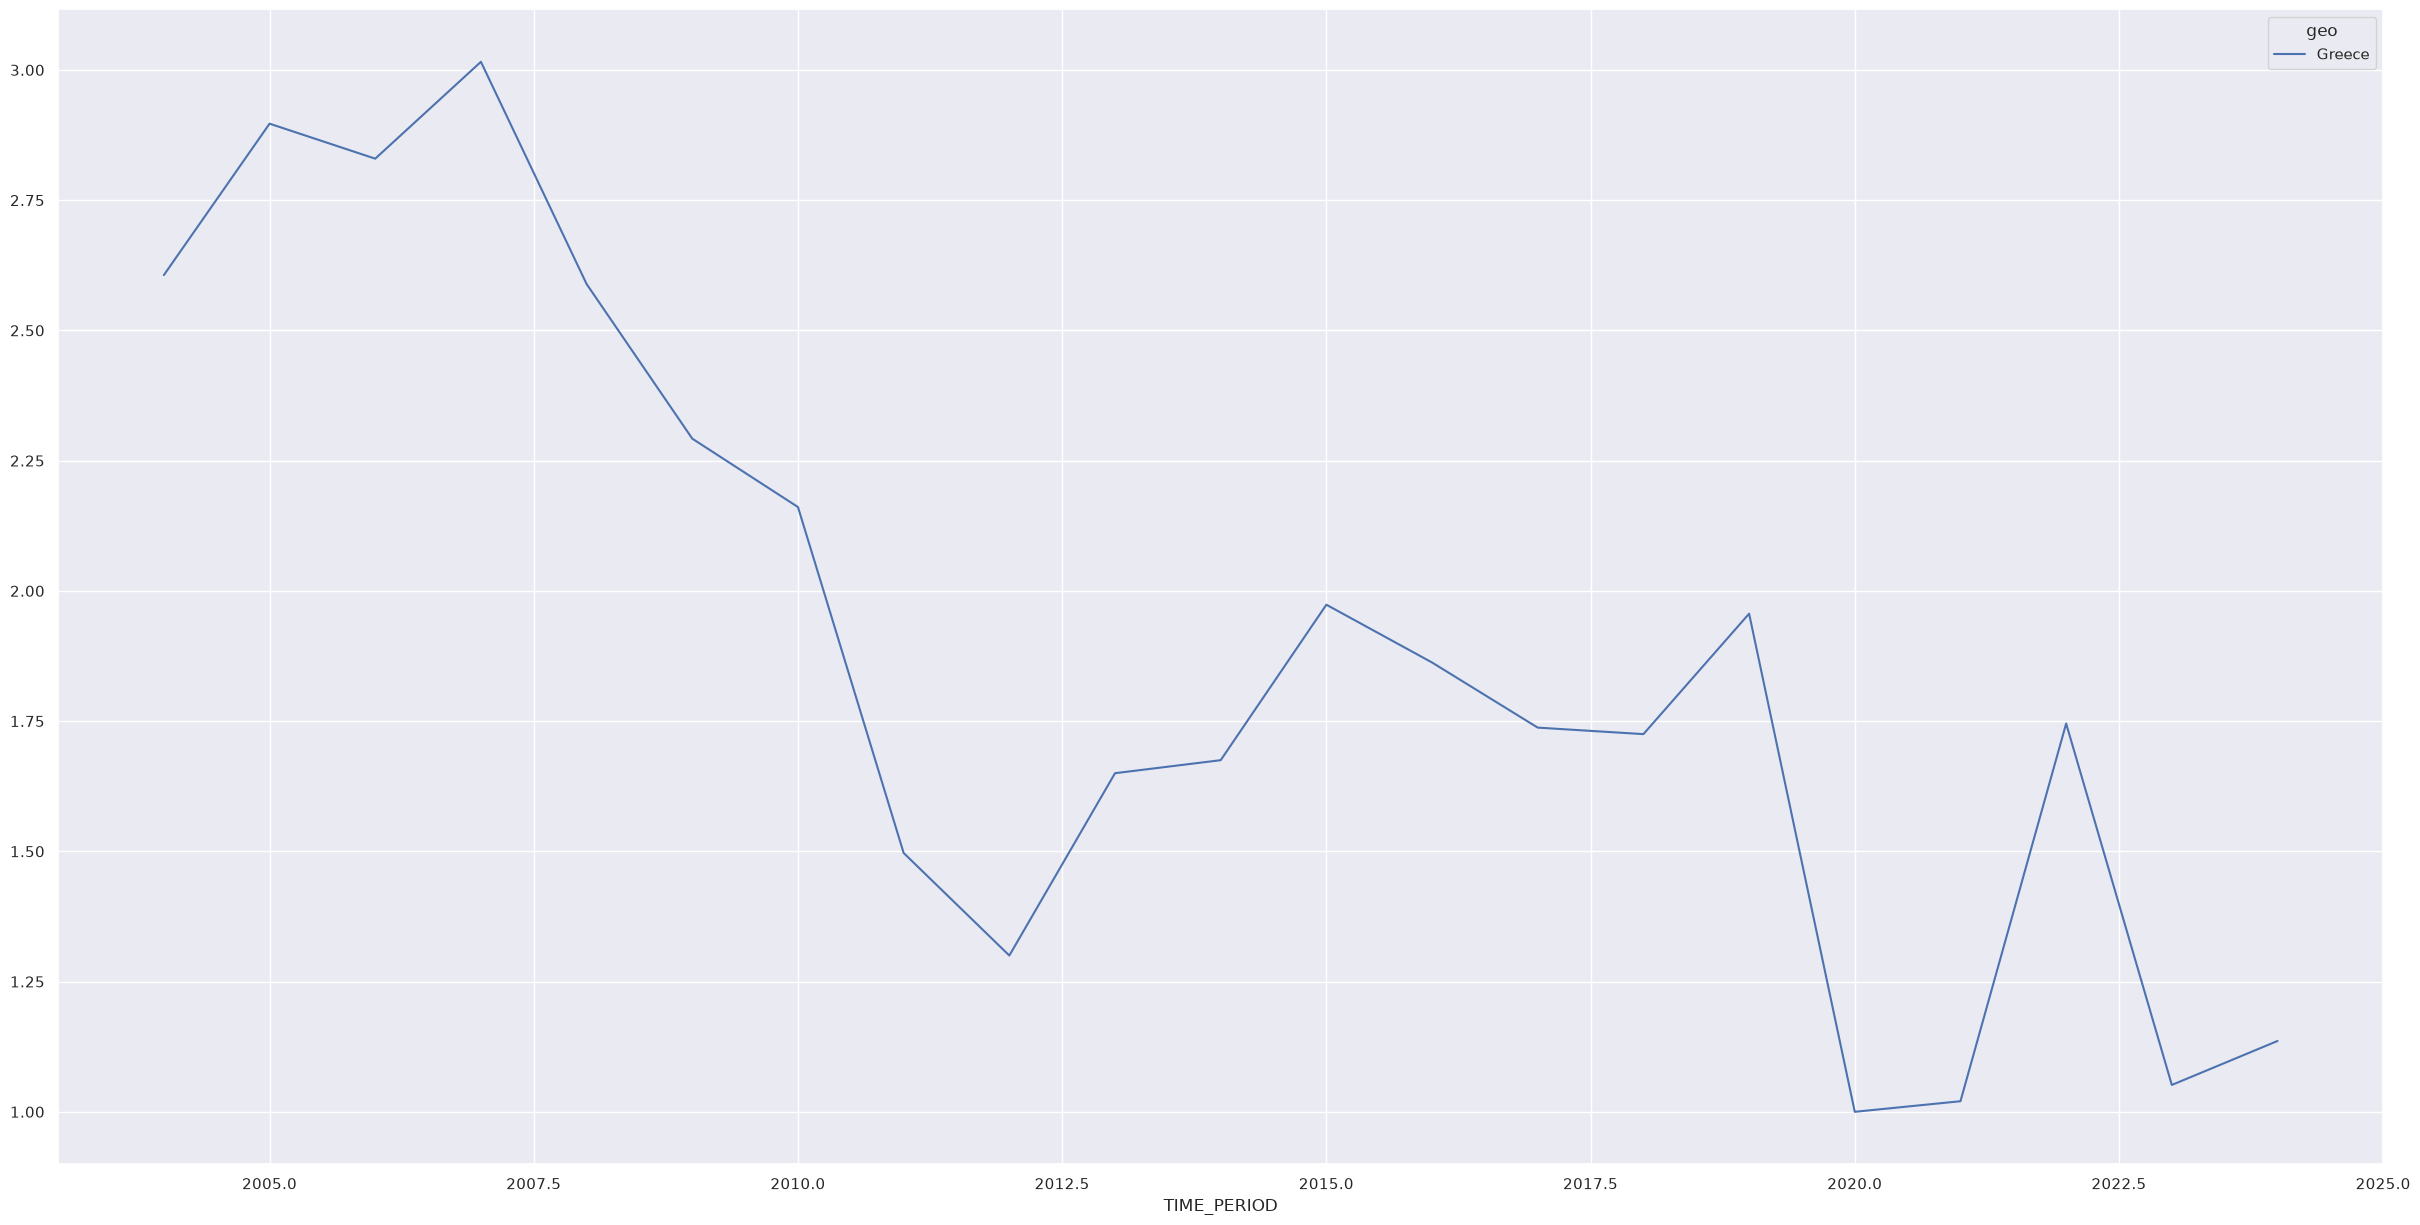

In [94]:
cp_idx = country_passengers / country_passengers.agg('min')
sns.set_theme()
sns.set(rc={"figure.figsize":(30, 15)})
sns.lineplot(cp_idx.iloc[:, 10:11])

In [95]:
cp_idx

geo,Austria,Bosnia and Herzegovina,Bulgaria,Croatia,Czechia,Denmark,Estonia,Finland,France,Germany,...,Netherlands,Norway,Portugal,Romania,Slovakia,Slovenia,Spain,Sweden,Switzerland,Türkiye
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
2004,1.121898,NaN,NaN,2.609375,1.016687,1.502792,1.000000,1.188652,1.378908,1.319639,...,1.583261,1.471910,1.463909,2.322043,1.131539,2.056213,1.685572,1.075620,NaN,3.445395
2005,1.177627,NaN,NaN,2.738839,1.030130,1.512944,1.284974,1.233333,1.425732,1.302966,...,1.653536,1.529775,1.486149,2.146505,1.108177,2.118343,1.753814,1.110004,NaN,3.313158
2006,1.207729,NaN,2.156530,2.950893,1.069530,1.547462,1.331606,1.255319,1.479973,1.368876,...,1.733850,1.591573,1.512290,2.175269,1.123921,2.142012,1.792703,1.198081,NaN,3.471711
2007,1.242983,NaN,2.150268,3.511161,1.065822,1.564213,1.419689,1.339716,1.519879,1.375187,...,1.781427,1.661798,1.555599,2.009677,1.099543,2.189349,1.771310,1.278311,NaN,3.653289
2008,1.405424,NaN,2.072451,3.948661,1.046508,1.590609,1.419689,1.436879,1.604347,1.433082,...,1.808885,1.754494,1.643777,1.870430,1.166074,2.263314,1.944693,1.388564,1.334666,3.353289
2009,1.380881,NaN,1.912343,4.022321,1.000000,1.563706,1.290155,1.374468,1.643178,1.411836,...,1.836343,1.730337,1.643777,1.647312,1.149822,2.286982,1.911692,1.410365,1.394842,3.535526
2010,1.391593,NaN,1.869410,3.819196,1.013443,1.609391,1.279793,1.403901,1.659218,1.440193,...,NaN,1.789888,1.603980,1.461559,1.172676,2.156805,1.852653,1.389685,1.439786,3.612500
2011,1.461424,NaN,1.841682,3.252232,1.030439,1.676396,1.259067,1.376596,1.675259,1.552836,...,NaN,1.728090,1.653141,1.361022,1.234637,2.038462,1.901410,1.417591,1.461956,2.632895
2012,1.520136,NaN,1.672630,2.410714,1.111867,1.711675,1.217617,1.430851,1.691299,1.632845,...,NaN,1.737079,1.483808,1.223118,1.248857,1.949704,1.861194,1.469042,1.446346,1.977632


In [96]:
## Divisione per popolazione

In [97]:
df3 = df.copy()
df3['Passengers_Mil_KM'] = (1_000_000 * df3['Passengers_Mil_KM'])/df3['population']

In [98]:
countries = df['geo'].unique()
countries = [c for c in countries if c not in ['Ukraine', 'Belgium']]
def get_subset(df, part):
    end = int(len(countries) / 4 * part)
    start = int(end - len(countries)/4)
    print(f"{start}:{end}")
    return df[df['geo'].str.match('|'.join(countries[start:end]))]

0:8


<Axes: xlabel='TIME_PERIOD', ylabel='Passengers_Mil_KM'>

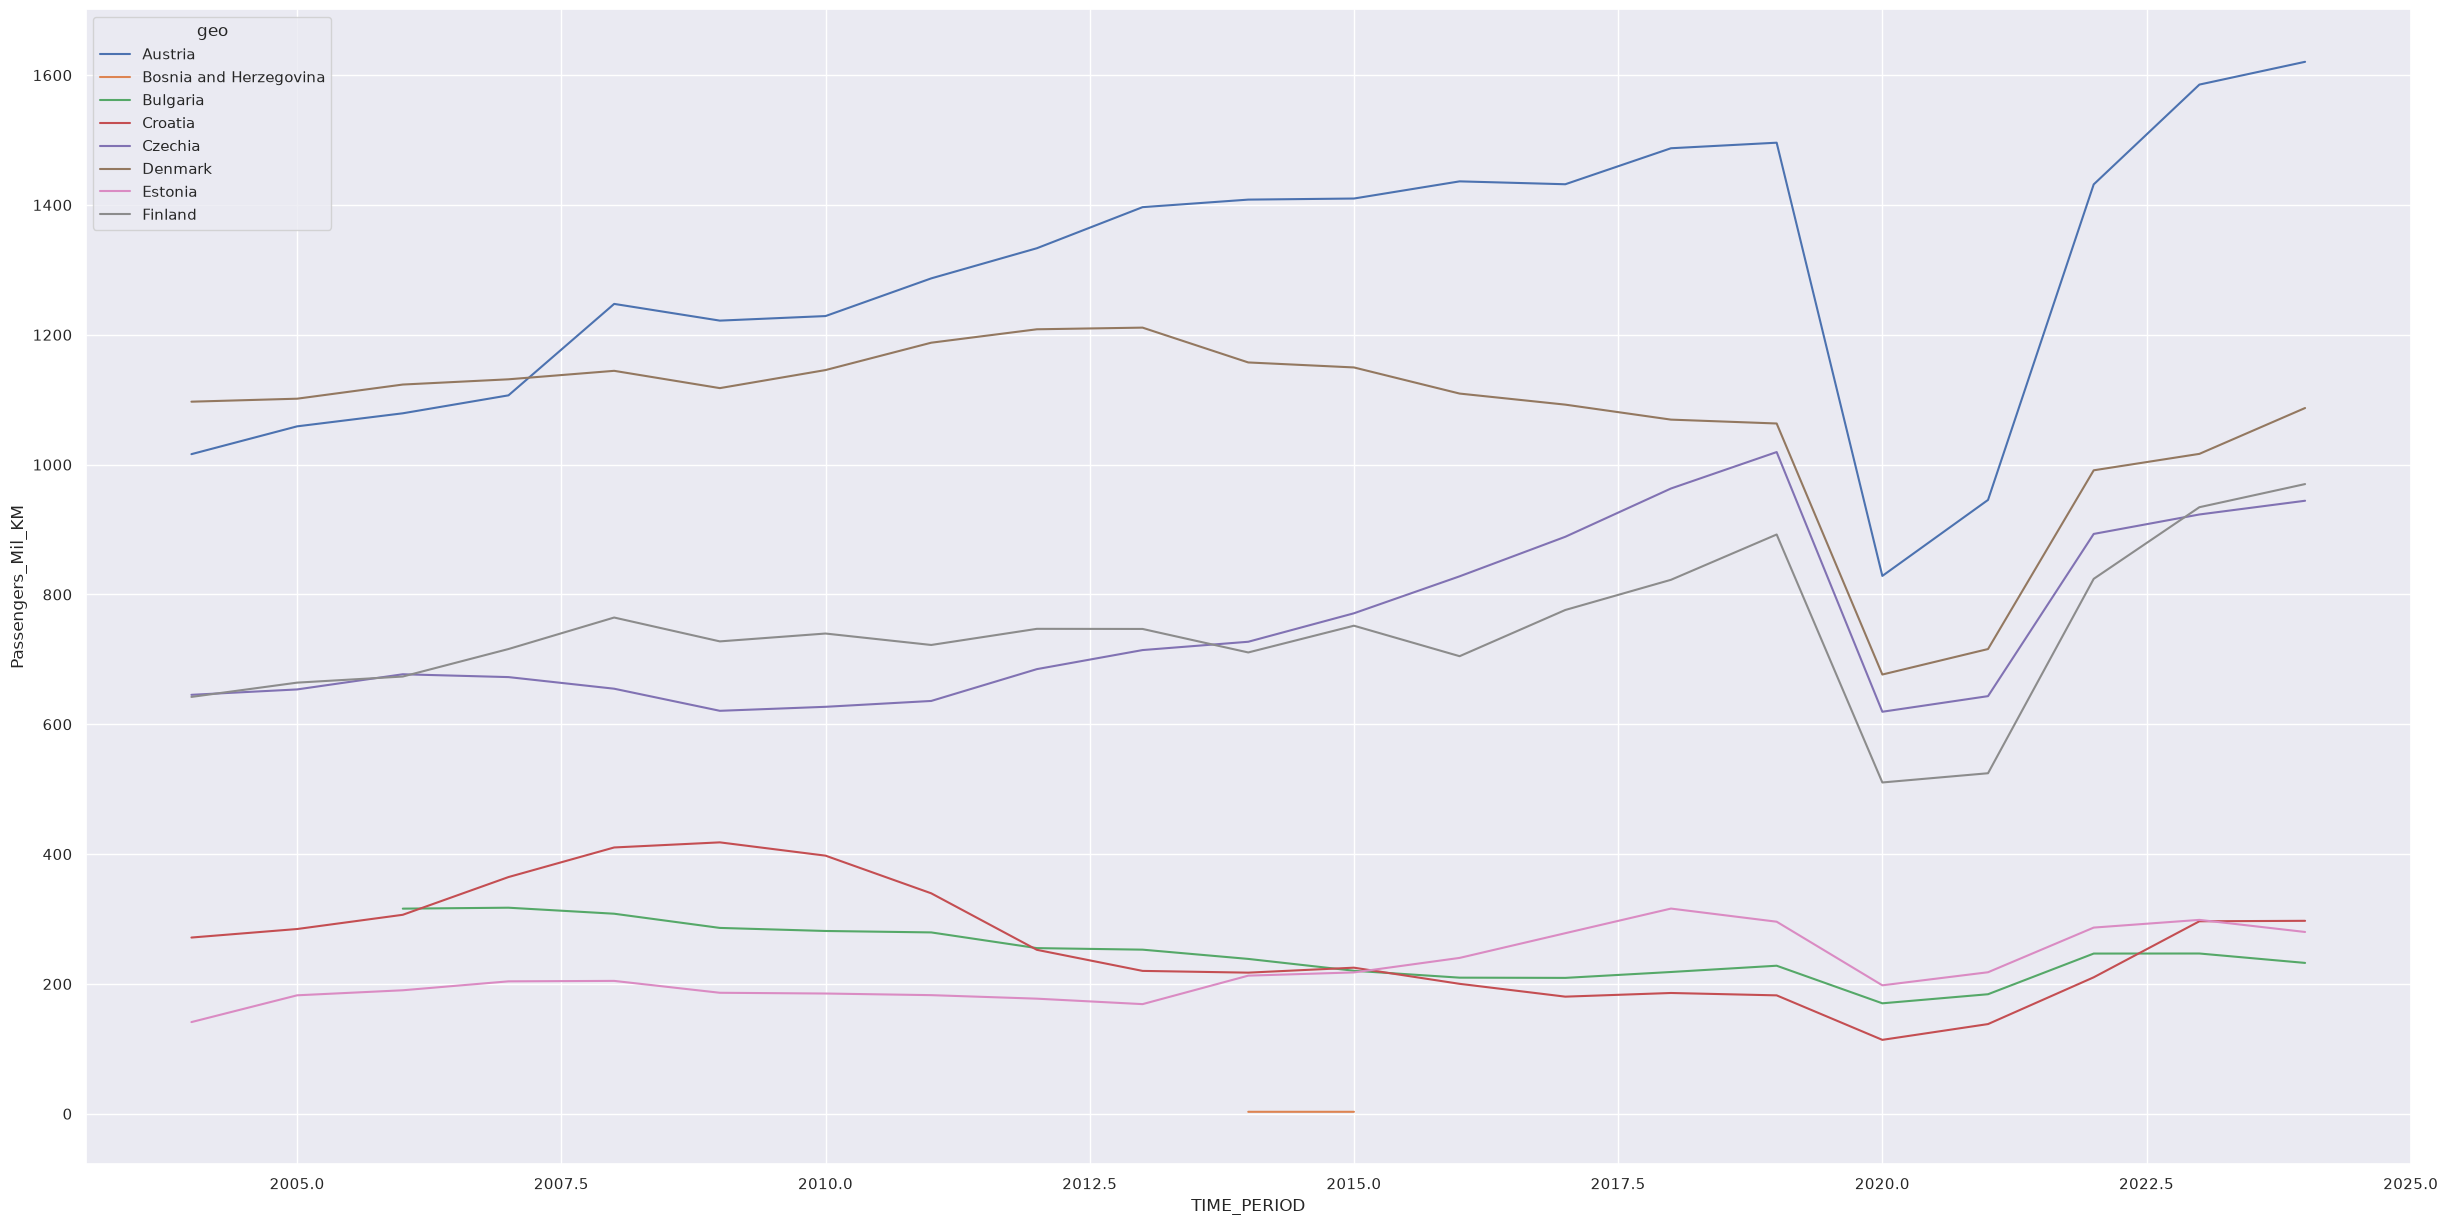

In [99]:
sns.lineplot(get_subset(df3, 1), x='TIME_PERIOD', y='Passengers_Mil_KM', hue='geo')

8:16


(0.0, 3000.0)

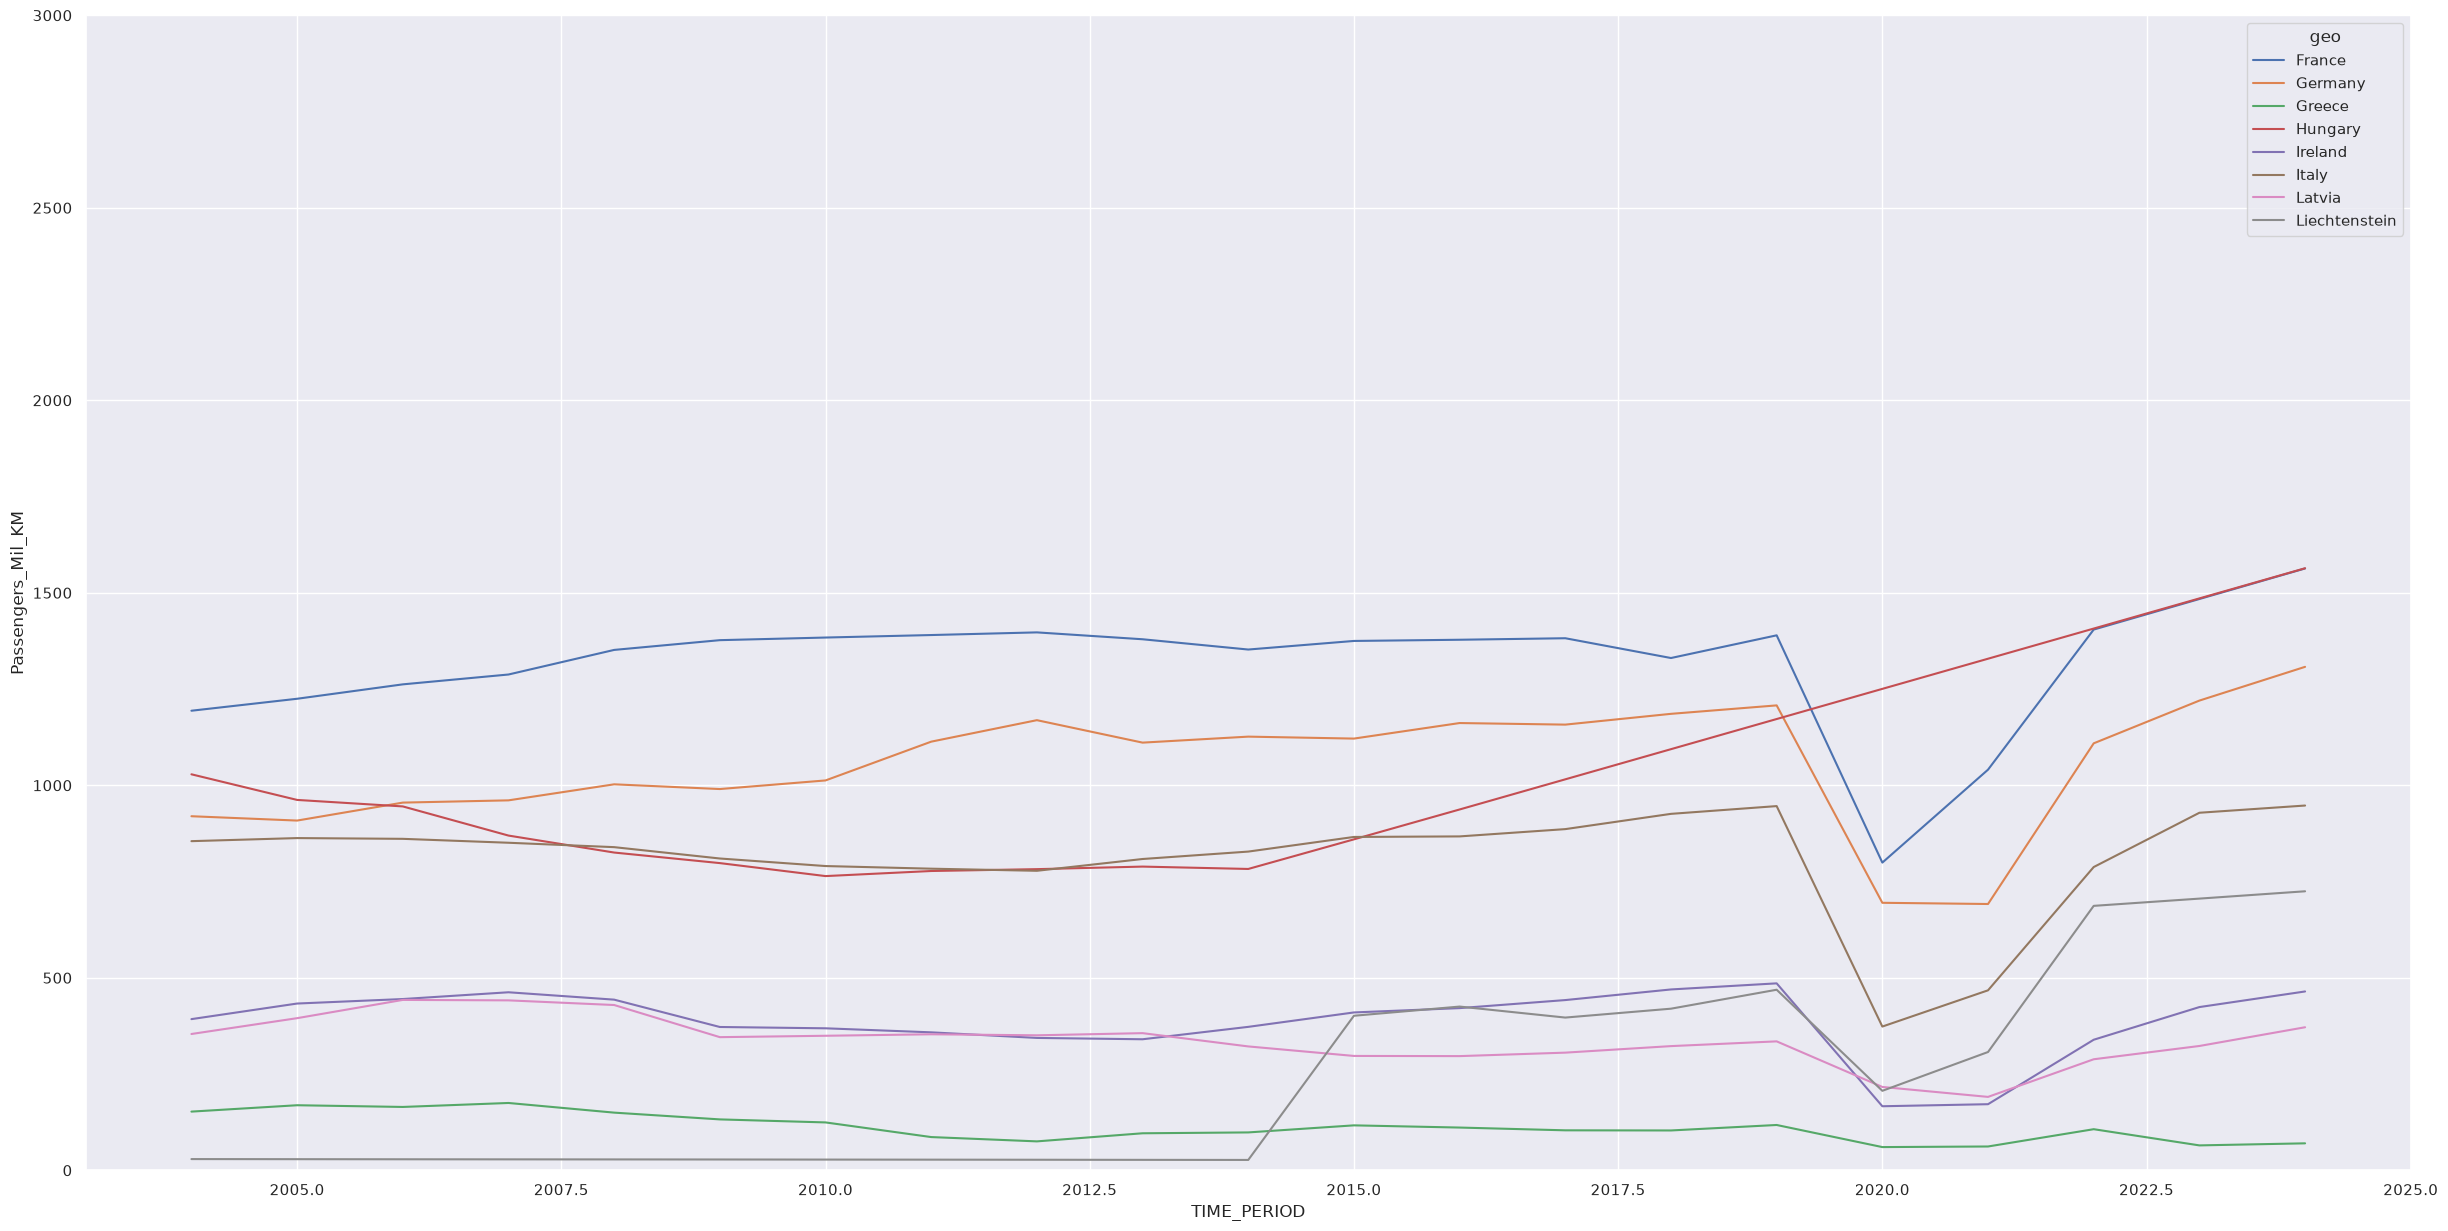

In [171]:
axis = sns.lineplot(get_subset(df3, 2), x='TIME_PERIOD', y='Passengers_Mil_KM', hue='geo')
axis.set_ylim(0, 3000)

16:24


(0.0, 3000.0)

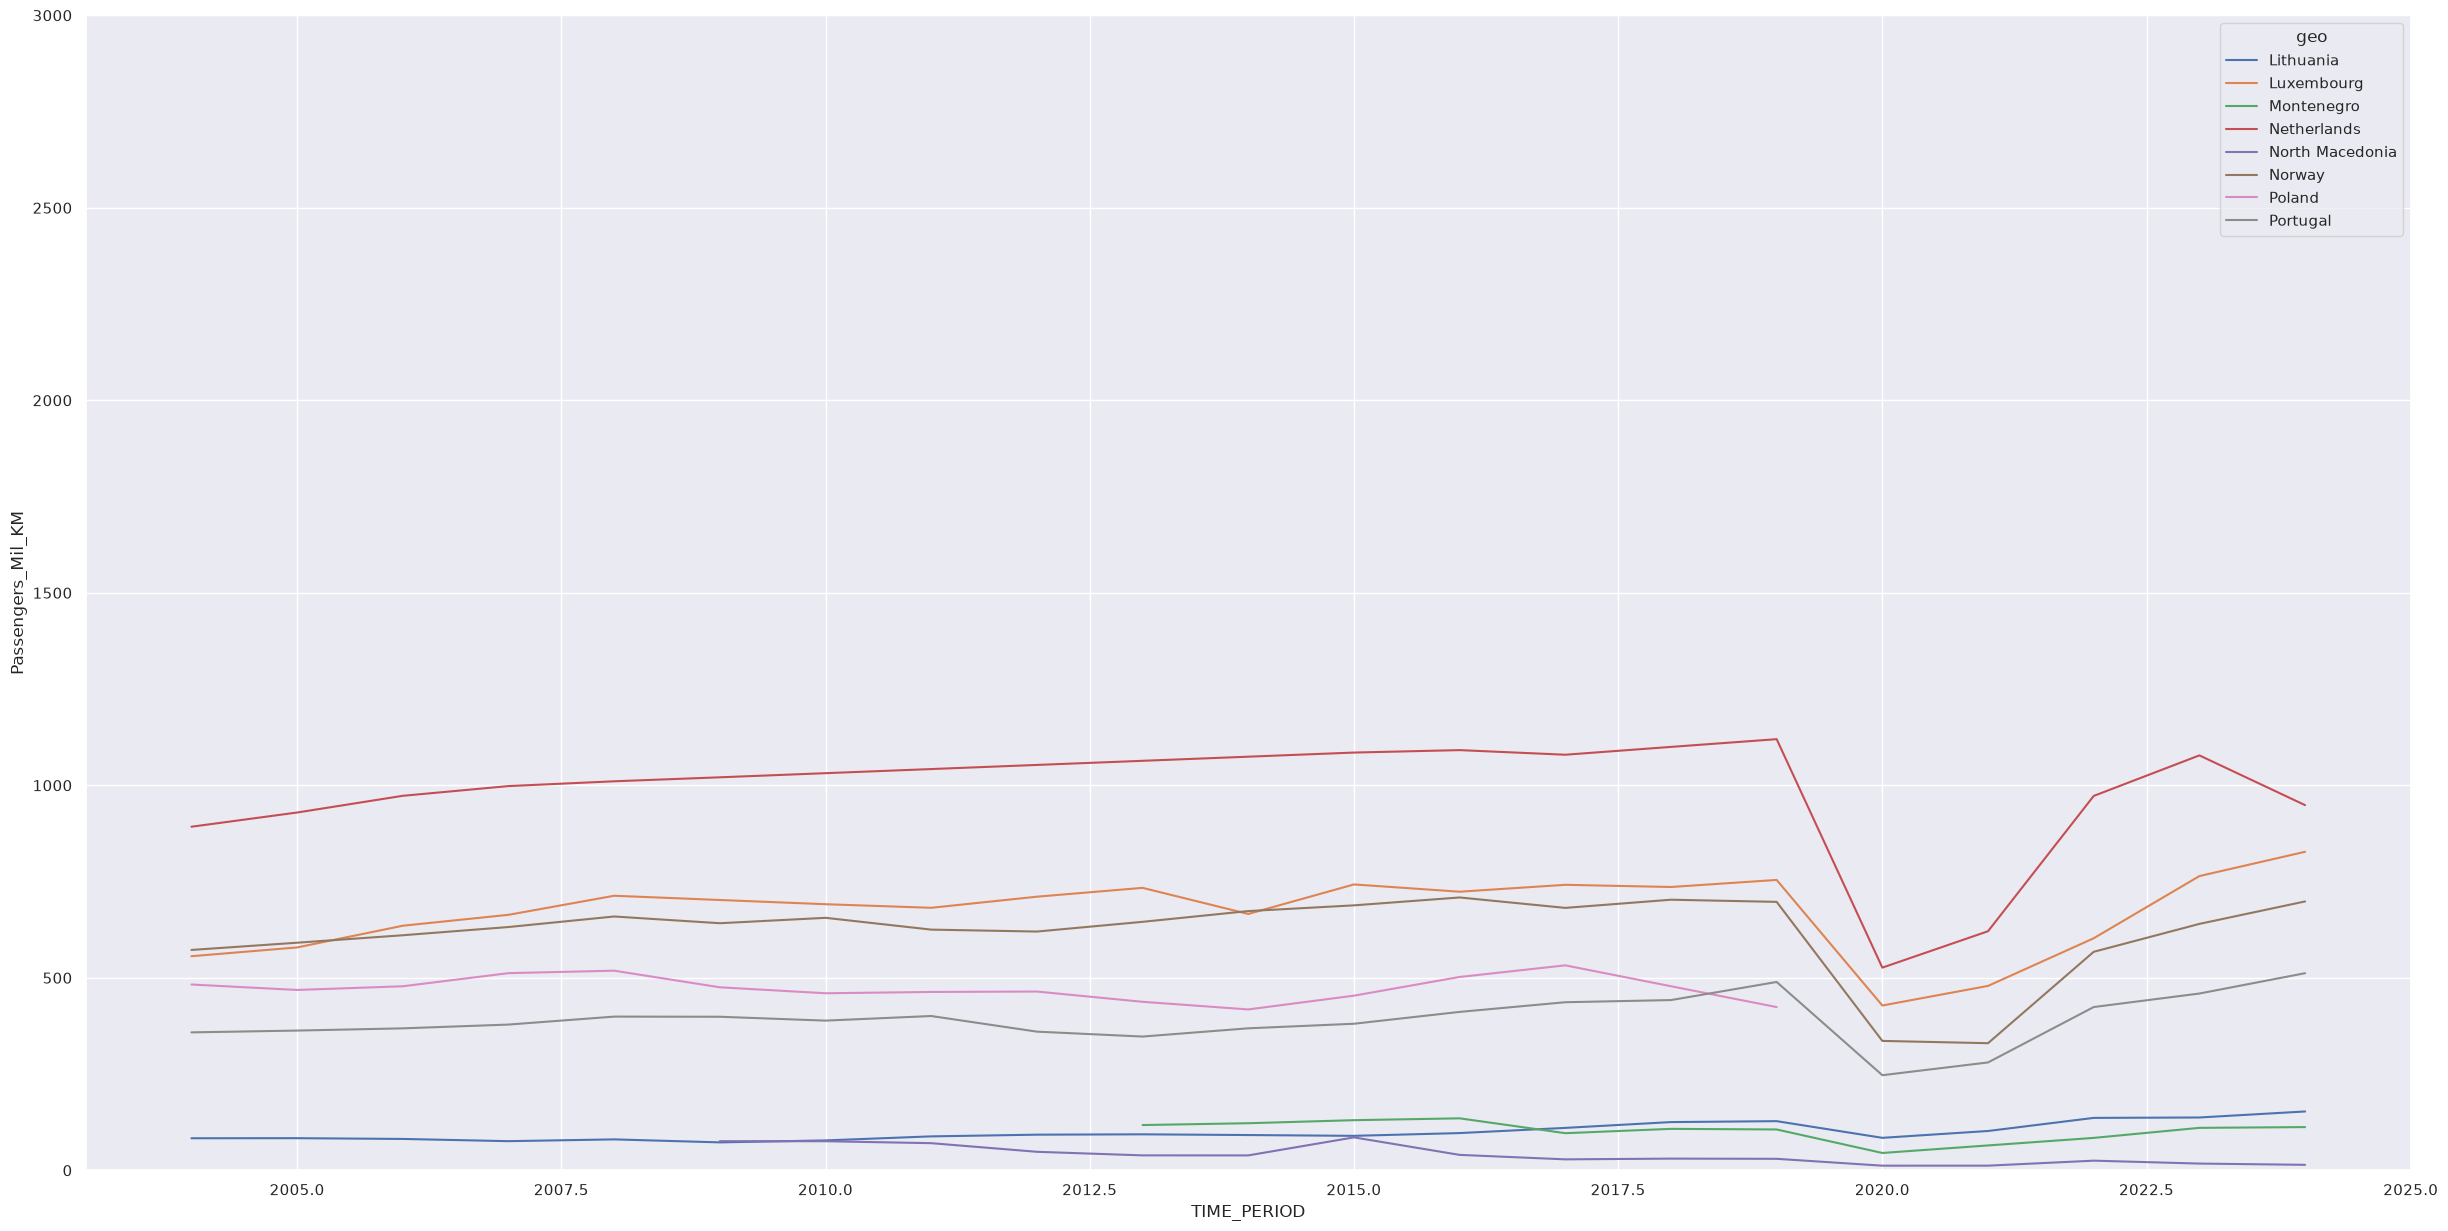

In [170]:
axis = sns.lineplot(get_subset(df3, 3), x='TIME_PERIOD', y='Passengers_Mil_KM', hue='geo')
axis.set_ylim(0, 3000)

24:32


(0.0, 3000.0)

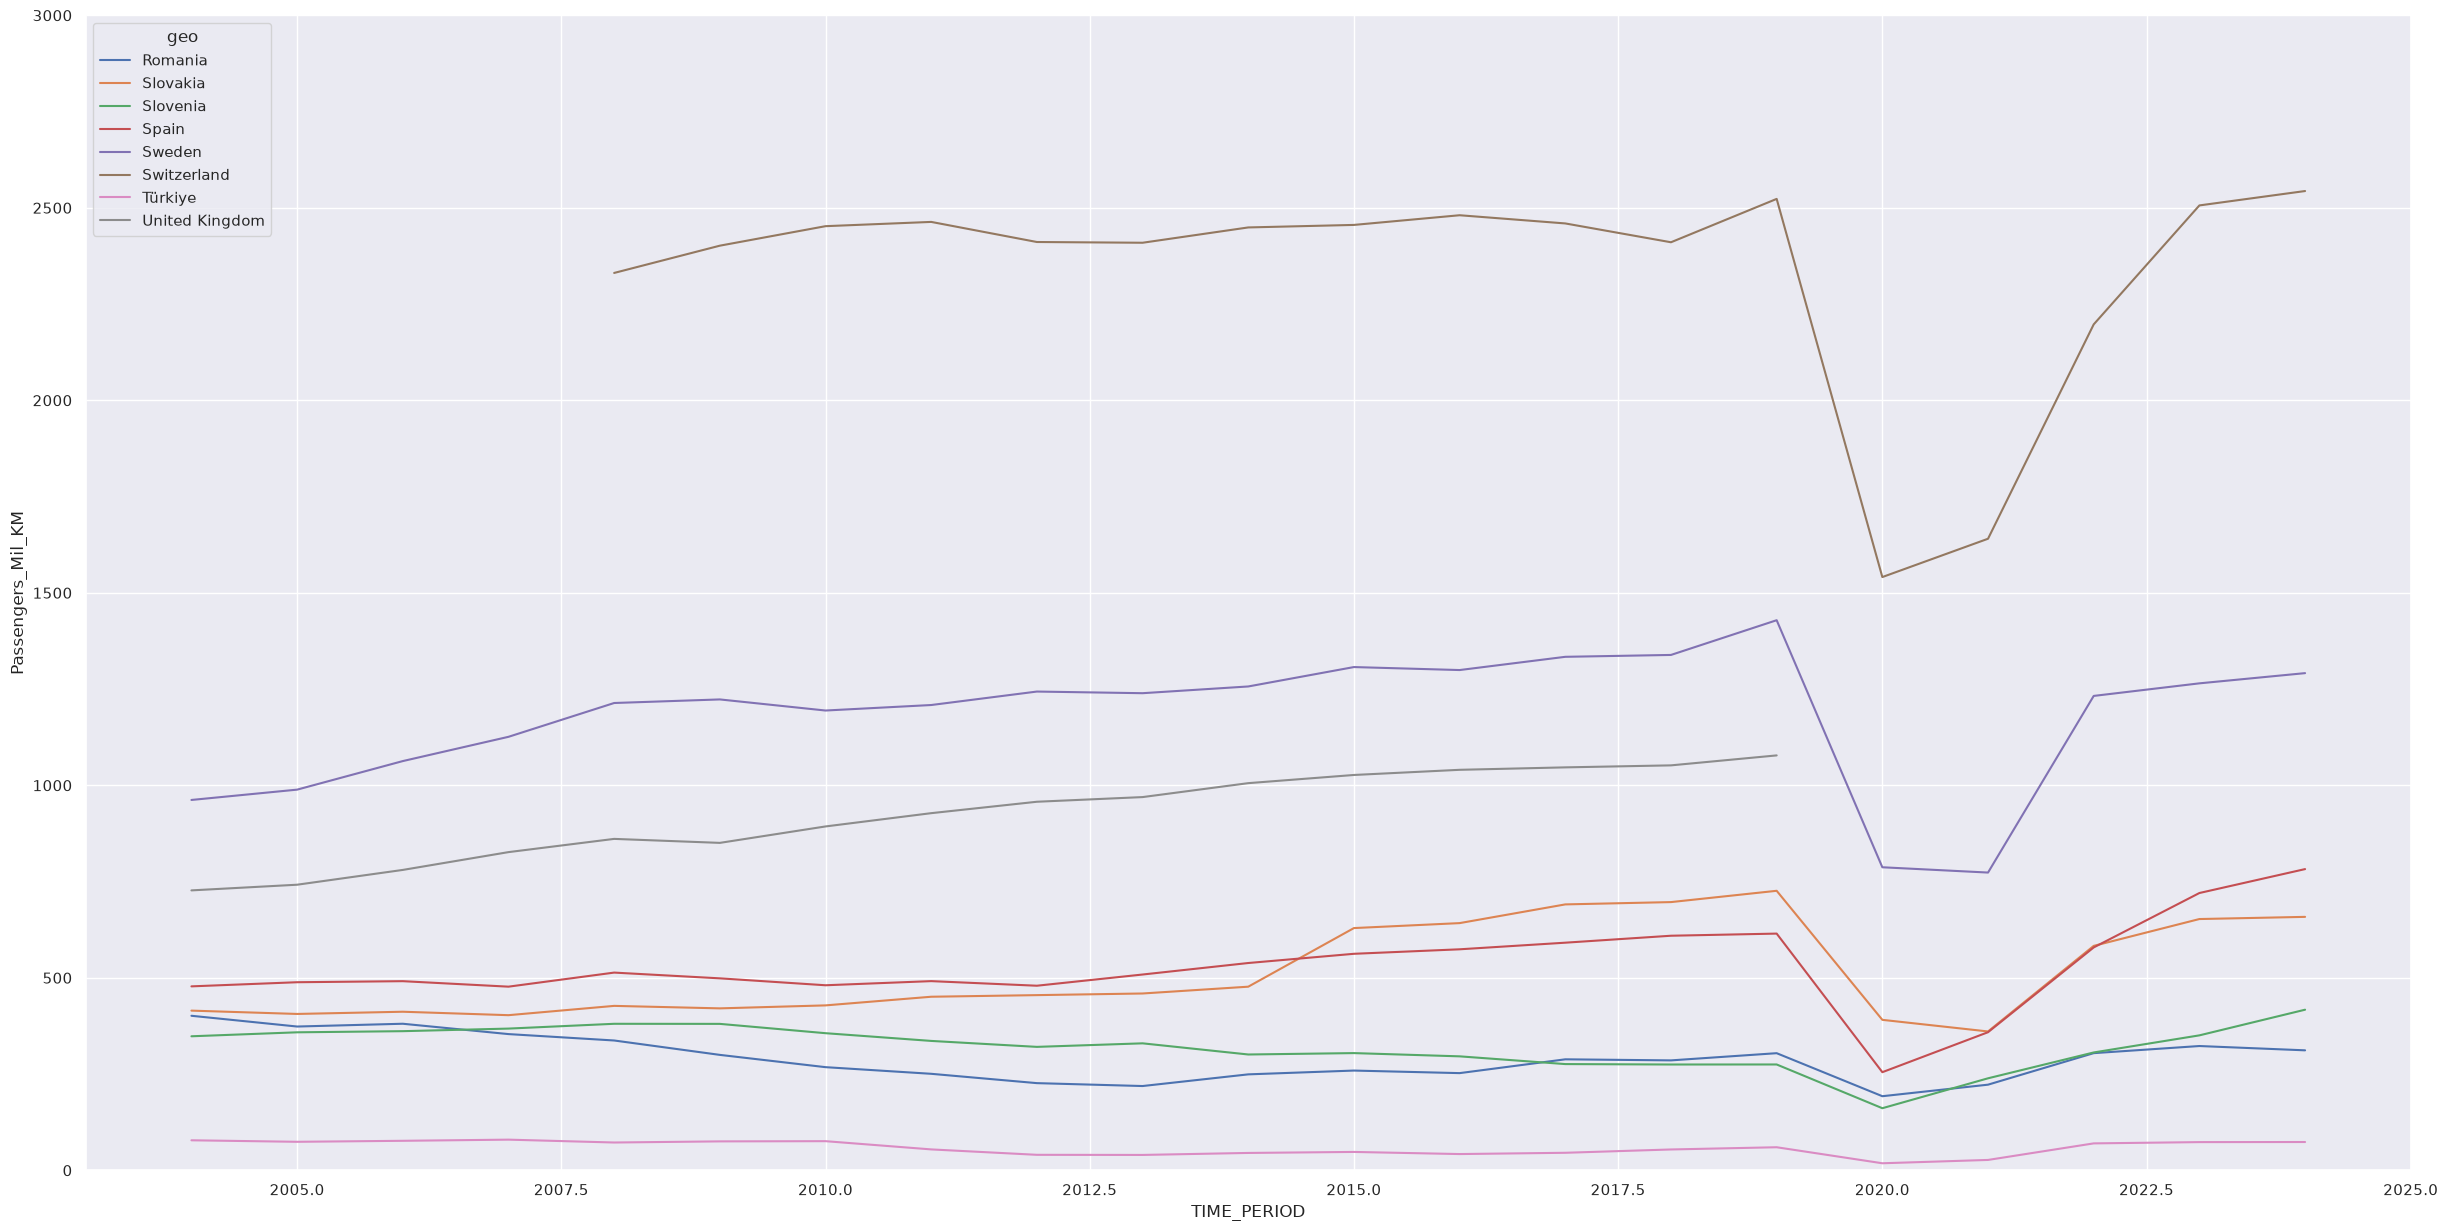

In [169]:
axis = sns.lineplot(get_subset(df3, 4), x='TIME_PERIOD', y='Passengers_Mil_KM', hue='geo')
axis.set_ylim(0, 3000)scale

<Axes: xlabel='TIME_PERIOD', ylabel='Passengers_Mil_KM'>

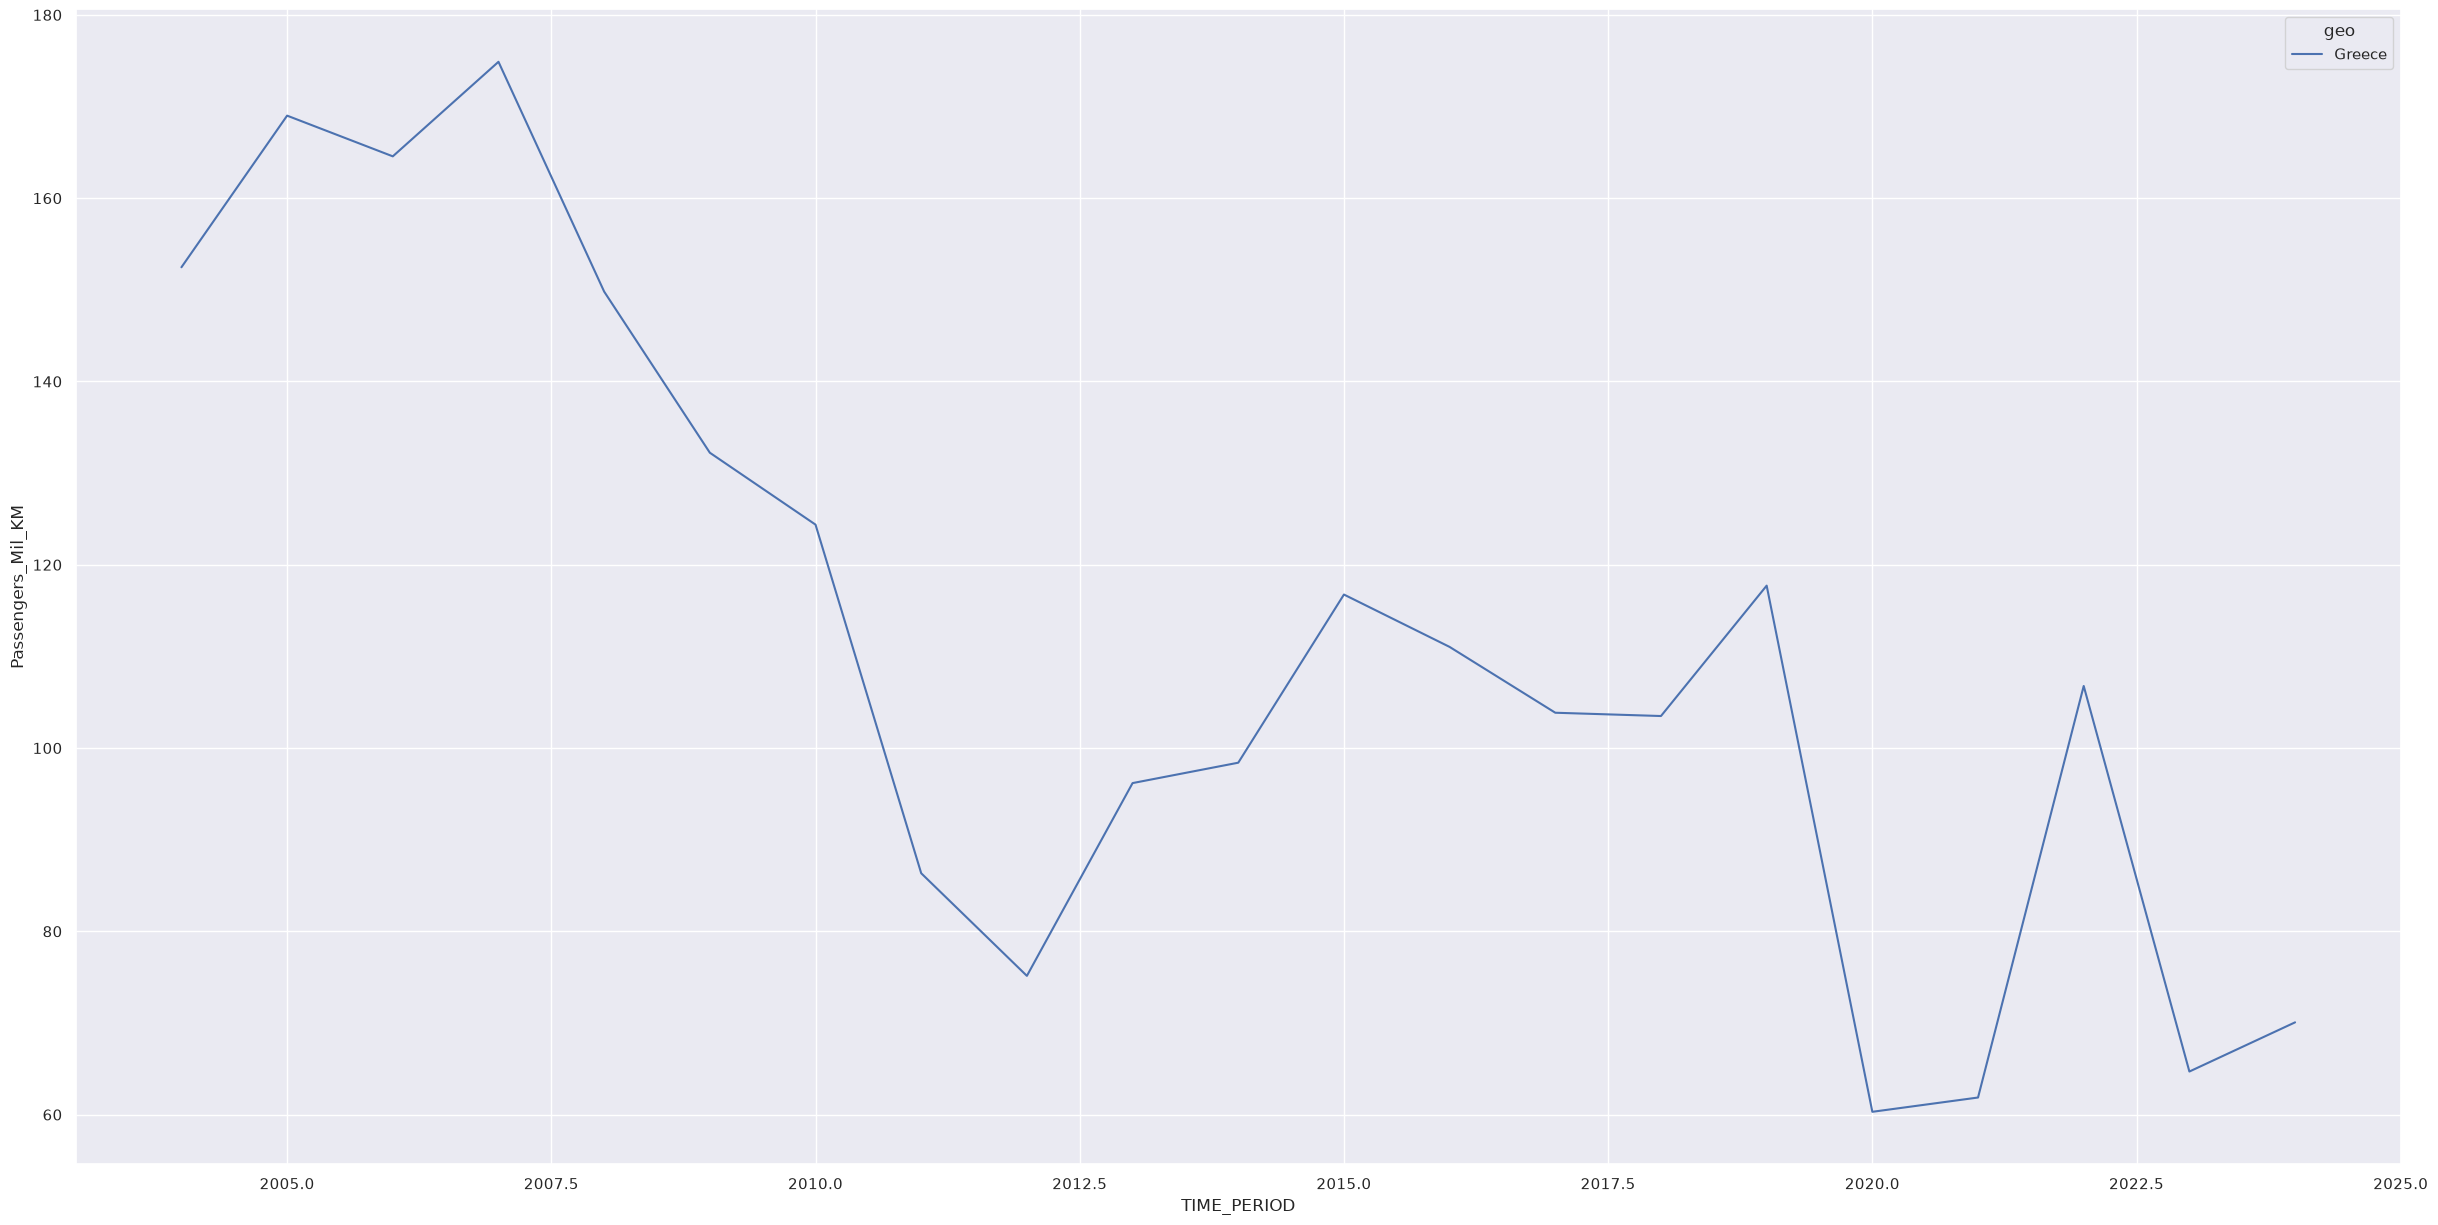

In [103]:
sns.lineplot(df3[df3['geo'] == 'Greece'], x='TIME_PERIOD', y='Passengers_Mil_KM', hue='geo')

In [104]:
df

,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita
0,Austria,2004,8274.0,5675.0,8142573.0,39620.0
1,Austria,2005,8685.0,5691.0,8201359.0,40270.0
2,Austria,2006,8907.0,5702.0,8254298.0,41370.0
3,Austria,2007,9167.0,5702.0,8282984.0,42790.0
4,Austria,2008,10365.0,5693.0,8307989.0,43270.0
...,...,...,...,...,...,...
654,United Kingdom,2015,66594.0,16241.0,64853393.0,NaN
655,United Kingdom,2016,68010.0,16253.0,65379044.0,NaN
656,United Kingdom,2017,68912.0,16320.0,65844142.0,NaN
657,United Kingdom,2018,69706.0,16289.0,66273576.0,NaN


In [144]:
mscaler = MinMaxScaler()
mscaler.fit(df.iloc[:, 2:])
df4 = df.copy()
df4.iloc[:, 2:] = mscaler.transform(df.iloc[:, 2:])
df4 = df4[df4['geo'] != 'Belgium']
df4 = df4[df4['geo'] != 'Hungary']
df4 = df4[df4['geo'] != 'Poland']
df4 = df4[df4['geo'] != 'Bosnia and Herzegovina']
df4 = df4[df4['geo'] != 'Liechtenstein']
df4 = df4[df4['geo'] != 'Ukraine']
df4 = df4[df4['geo'] != 'United Kingdom']
df4['Passengers_Mil_KM'] = df4['Passengers_Mil_KM'].interpolate(method='linear', limit_direction='forward', limit_area='inside')
df4 = df4.reset_index()

In [145]:
df4.shape

(545, 7)

In [146]:
km = KMeans(4)
km.fit(df4.iloc[:, 2:])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 5)",

In [160]:
tsne = TSNE()
df_tsne = pd.DataFrame(tsne.fit_transform(df4.iloc[:, 2:]), columns=['C1', 'C2'])
df_tsne.shape

(545, 2)

In [161]:
df_tsne['cluster'] = km.labels_
# Convert the column to the 'category' data type
df_tsne['cluster'] = pd.Categorical(df_tsne['cluster'], categories=[0,1,2,3], ordered=True)
df_tsne['country'] = df4['geo']
df_tsne['year'] = df4['TIME_PERIOD']


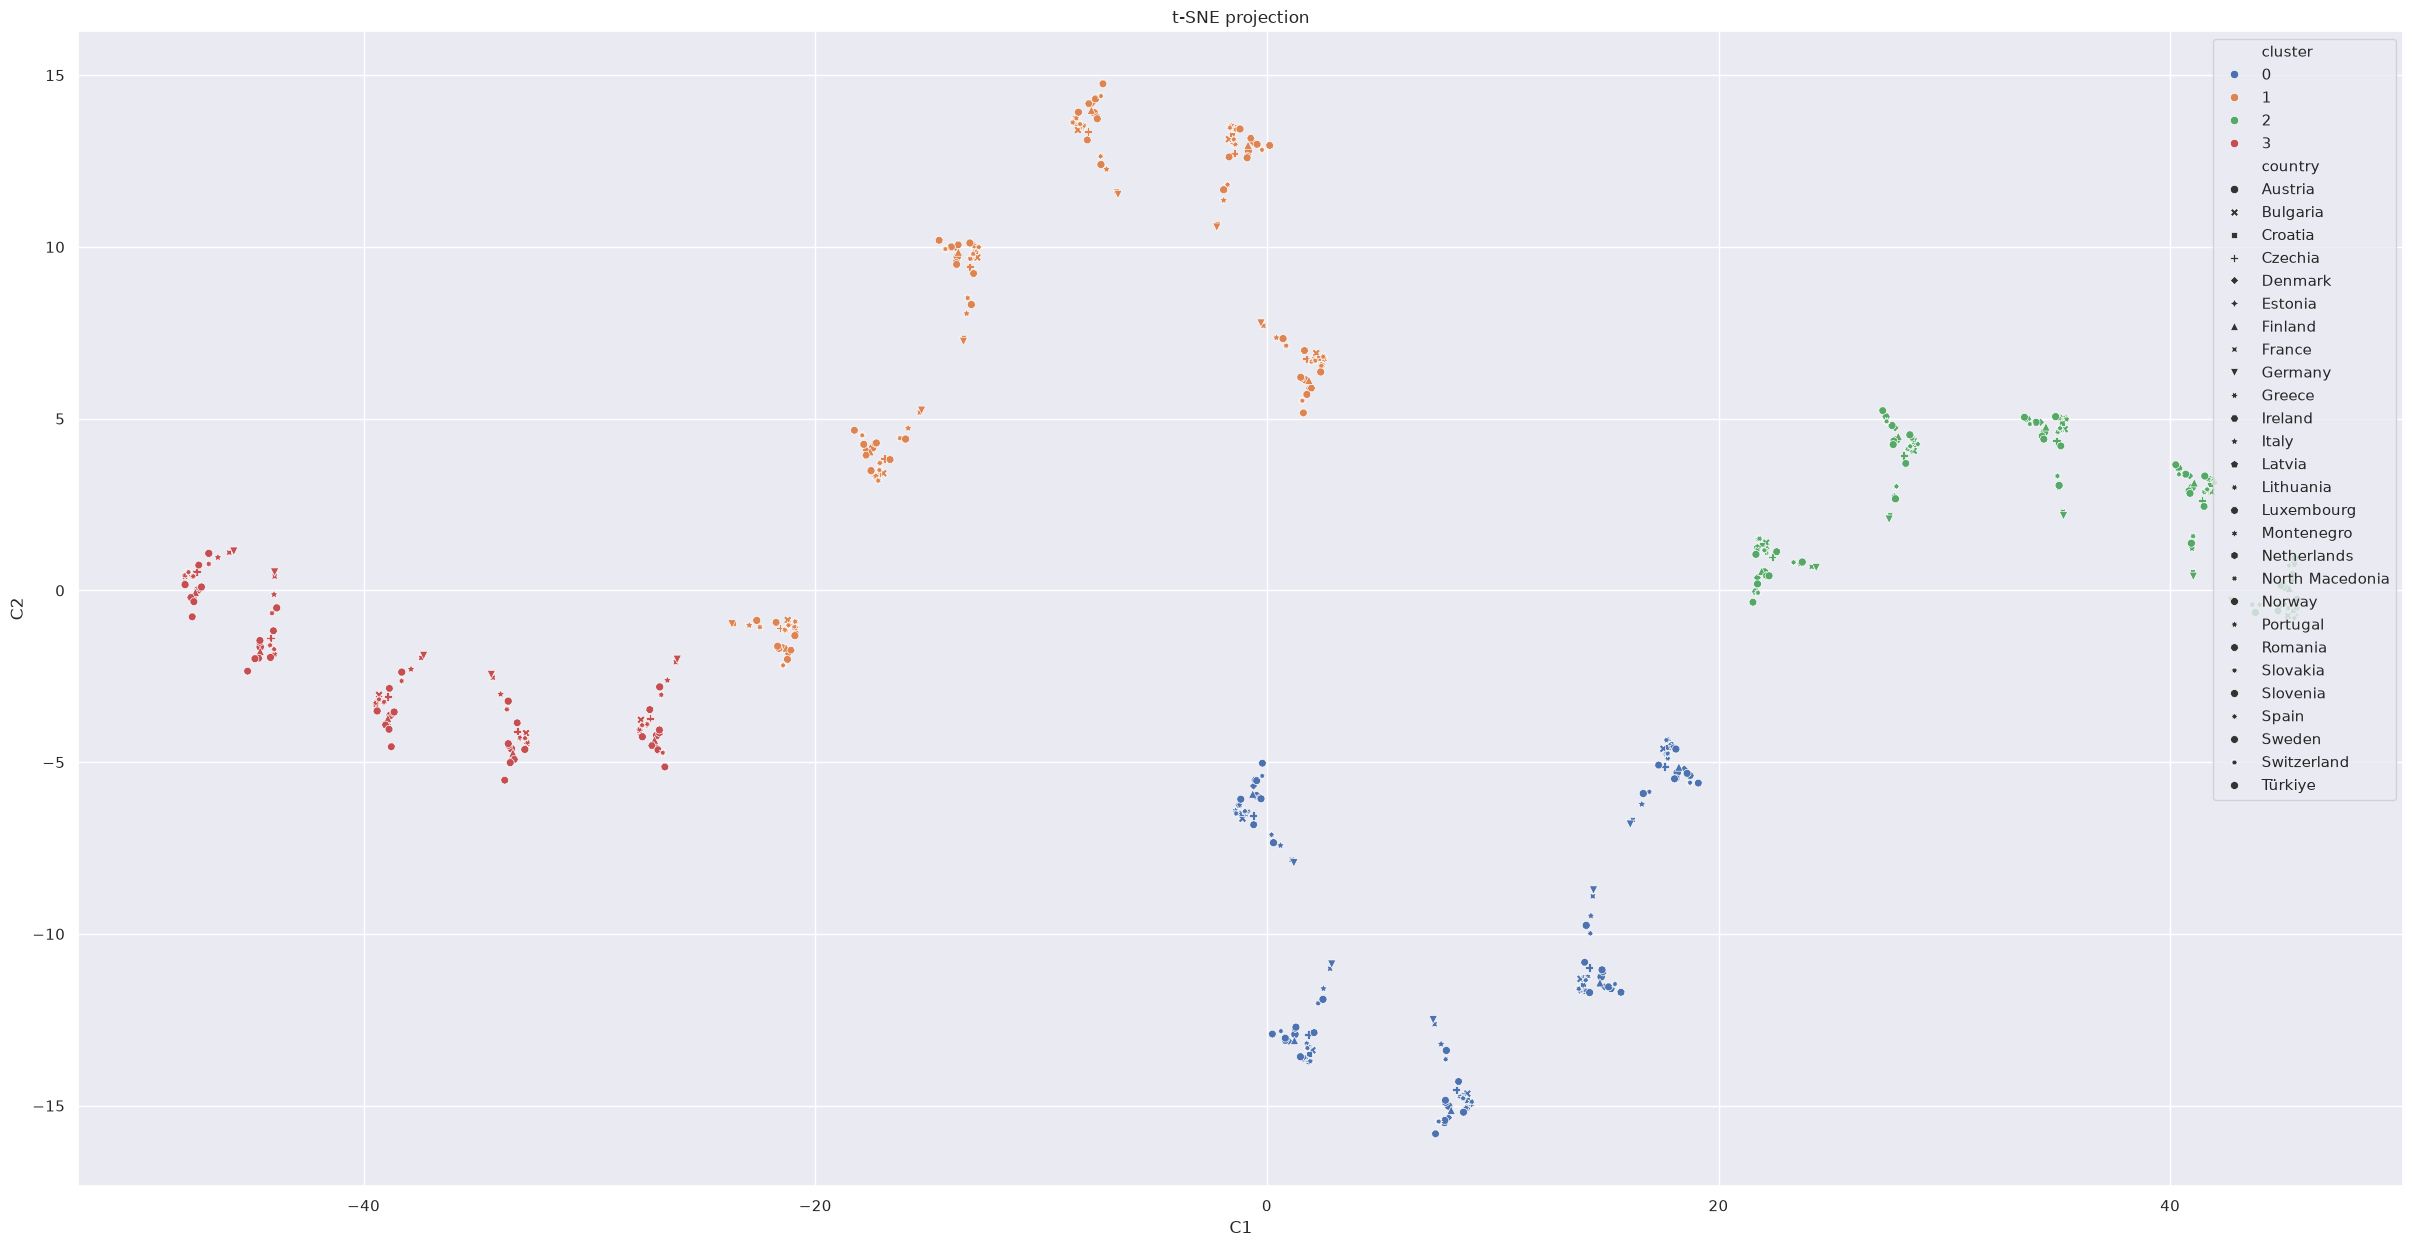

In [163]:
# representing the data
axes = sns.scatterplot(df_tsne, x='C1', y='C2', hue='cluster', style='country')
axes.title.set_text('t-SNE projection')

In [167]:
df_tsne[df_tsne['cluster'] == 3]['year'].unique()

array([2004, 2005, 2006, 2007, 2008])